# The Rebalancing Bonus ♻️
### Is rebalancing really a *free lunch* that adds return on top of the risk control?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Controls risk?: Confirmed](https://img.shields.io/badge/Controls_risk%3F-Confirmed-8b949e?style=flat-square)

You'll hear it everywhere: rebalancing your portfolio back to its target weights *pays you* — a **rebalancing bonus**, *volatility harvesting*, *Shannon's Demon*. Sell high, buy low, automatically, forever. We take a plain 50/50 stocks/bonds book (SPY + long Treasuries, dividends included), rebalance it, and ask the only two questions that matter: does it **add return** (no), and does it **control risk** (yes).

> 📓 **This is the plain-language layer.** The variance identity, the *t*-stats and the bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (free_rebalance/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from free_rebalance import data, strategy

AS_OF = "2026-06-12"
frame = data.load_real(("SPY", "TLT"), mode="total_return").loc[:AS_OF]
annual    = strategy.run_portfolio(frame, freq="annual",    cost_bps=10.0)
quarterly = strategy.run_portfolio(frame, freq="quarterly", cost_bps=10.0)
drift     = strategy.run_portfolio(frame, freq="drift",     cost_bps=10.0)
bonus_a = annual['cagr'] - drift['cagr']
print(f"basket SPY/TLT total return: {len(frame):,} rows  {frame.index[0].date()} -> {frame.index[-1].date()}  fp={data.fingerprint(frame)}")
print(f"rebalanced(A) CAGR {annual['cagr']*100:.2f}%  vol {annual['vol']*100:.1f}%  Sharpe {annual['sharpe']:.3f}")
print(f"drift (B&H)   CAGR {drift['cagr']*100:.2f}%  vol {drift['vol']*100:.1f}%  Sharpe {drift['sharpe']:.3f}")
print(f"realised rebalancing bonus (annual) = {bonus_a*100:+.2f} pts/yr CAGR")


basket SPY/TLT total return: 6,007 rows  2002-07-30 -> 2026-06-12  fp=f644f699f3af
rebalanced(A) CAGR 8.22%  vol 9.6%  Sharpe 0.875
drift (B&H)   CAGR 8.82%  vol 10.3%  Sharpe 0.874
realised rebalancing bonus (annual) = -0.59 pts/yr CAGR


## The answer first 🎯

| Question | Answer |
|---|---|
| Does rebalancing add return vs just holding the basket? | **No** — the rebalanced book earned **8.22%/yr** vs **8.82%/yr** for drift, about **0.6 points/yr *less*** (net of 10 bps/rebalance). |
| Is the risk-adjusted return any better? | **No** — Sharpe **0.875** vs **0.874**, a dead heat. |
| So what *does* rebalancing buy you? | **Risk control** — lower volatility (9.6% vs 10.3%) and a book that stays at its target mix instead of drifting stock-heavy. |

## 1 · The claim

*"Rebalancing is a free lunch. By selling whatever went up and buying whatever went down, you mechanically **harvest volatility** — the **rebalancing bonus** — so you get *extra return* on top of the risk control. Even Claude Shannon showed two assets can compound upward this way (*Shannon's Demon*)."* It's one of the most-repeated ideas in portfolio construction.

## 2 · So what?

If rebalancing reliably *added* return, it would be the rarest thing in finance: a free lunch with no risk attached. Every investor should crank up the frequency and harvest away. The stakes are exactly that big — so it deserves a fair, literal test against the honest alternative: *just holding the basket and never trading.*

## 3 · How would we even know?

We build a 50/50 SPY/TLT portfolio (total return) and run it two ways: **rebalanced** back to 50/50 each year (and each quarter), paying **10 bps** on whatever we trade, vs **drift** — the same starting weights left completely alone. The *rebalancing bonus* is simply: rebalanced return minus drift return. If the bonus is positive, the free lunch is real. If it's zero or negative, it isn't.

## 4 · The teardown — let's actually look

First, the two equity curves — rebalanced vs left to drift.

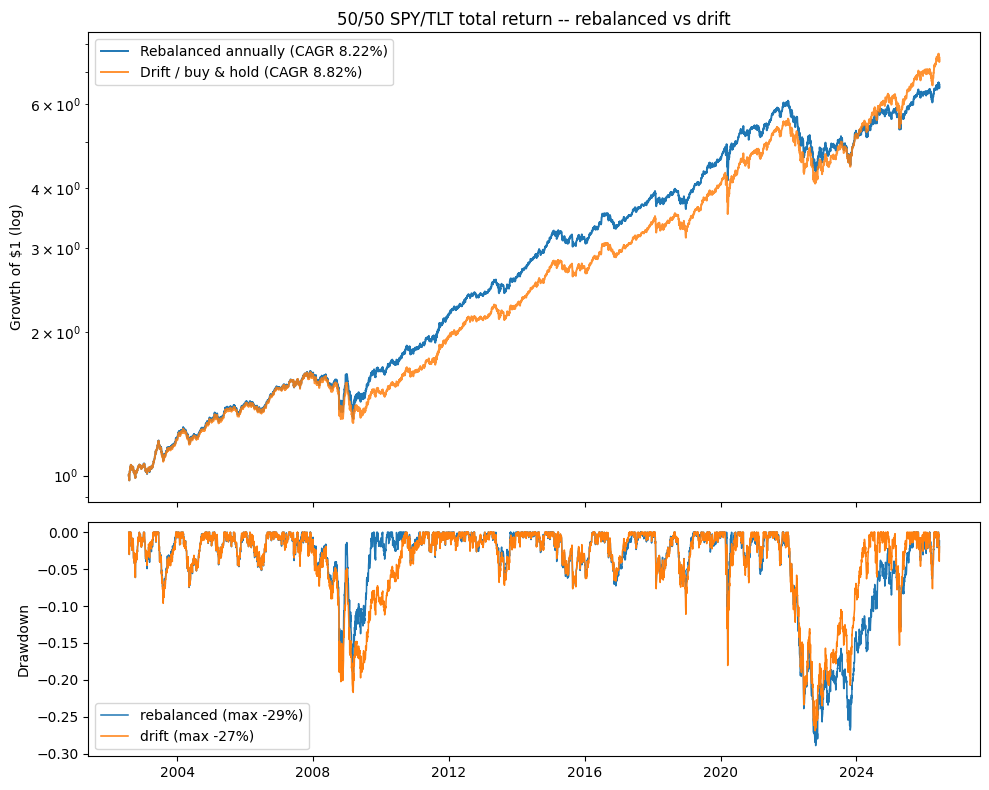

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])
ax1.plot(annual['equity'], label=f"Rebalanced annually (CAGR {annual['cagr']*100:.2f}%)", lw=1.4)
ax1.plot(drift['equity'], label=f"Drift / buy & hold (CAGR {drift['cagr']*100:.2f}%)", lw=1.4, alpha=.85)
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend()
ax1.set_title('50/50 SPY/TLT total return -- rebalanced vs drift')
for d, lab in [(annual, 'rebalanced'), (drift, 'drift')]:
    eq = d['equity']; dd = eq/eq.cummax()-1
    ax2.plot(dd, label=f"{lab} (max {dd.min()*100:.0f}%)", lw=1.1)
ax2.set_ylabel('Drawdown'); ax2.legend(); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

Look at the **end point**: the *drift* line finishes **higher**. Over this window the free lunch cost you money — the rebalanced book trailed by about **0.6 points a year**. Why? Stocks (SPY) ran away from bonds (TLT) for much of the period, and rebalancing kept *trimming the winner*.

Now the **bonus by sub-period** — does it flip with the regime?

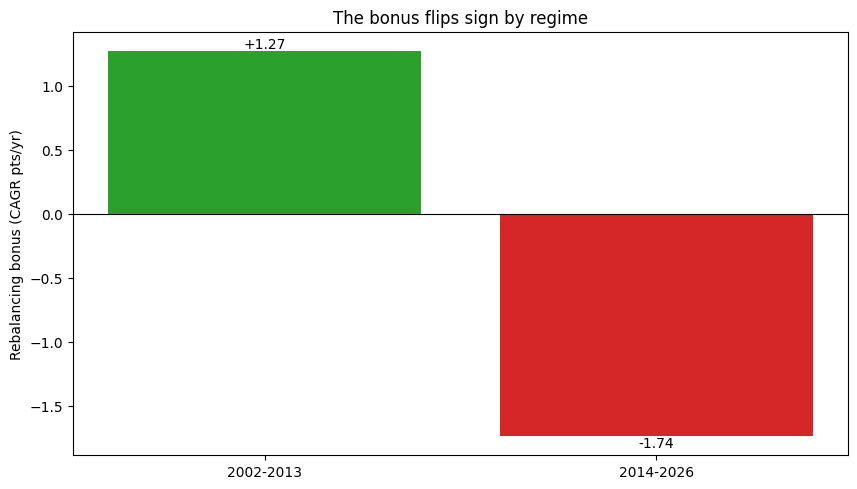

bonus by sub-period: [('2002-2013', 1.27), ('2014-2026', -1.74)]


In [3]:
yrs = frame.index.year
rows = []
for mask, lab in [(yrs <= 2013, '2002-2013'), (yrs >= 2014, '2014-2026')]:
    sub = frame.loc[mask]
    ra = strategy.run_portfolio(sub, freq='annual', cost_bps=10.0)
    rd = strategy.run_portfolio(sub, freq='drift',  cost_bps=10.0)
    rows.append((lab, (ra['cagr']-rd['cagr'])*100))
labels = [r[0] for r in rows]; vals = [r[1] for r in rows]
colors = ['C2' if v>0 else 'C3' for v in vals]
plt.bar(labels, vals, color=colors); plt.axhline(0, color='k', lw=.8)
plt.ylabel('Rebalancing bonus (CAGR pts/yr)'); plt.title('The bonus flips sign by regime')
for i,v in enumerate(vals): plt.text(i, v, f'{v:+.2f}', ha='center', va='bottom' if v>0 else 'top')
plt.show()
print('bonus by sub-period:', [(l, round(v,2)) for l,v in rows])

There it is: **+1.27 pts/yr** in 2002–13 (a choppy, mean-reverting decade where harvesting paid), then **-1.74 pts/yr** in 2014–26 (when stocks trended away and trimming them hurt). The bonus isn't a constant of nature — it's **regime-dependent**, and it can be negative.

## 5 · The verdict

- **Controls risk? → Confirmed.** Volatility 9.6% vs 10.3%, and the weights stay pinned at the target mix instead of drifting stock-heavy. *That* is the real product.
- **Signal → Weak.** The realised bonus is **-0.59 pts/yr** and isn't statistically distinguishable from zero (it even flips sign by regime).
- **Free lunch / adds return? → Mirage.** Rebalancing earned **0.6 pts/yr less** than just holding the basket, and the Sharpe was a wash.

## 6 · Could you actually trade it?

Sure — SPY and TLT are infinitely liquid and the trades are tiny. The catch isn't capacity, it's that there's **no return bonus to capture**. What rebalancing gives you — keeping your risk at the level you chose — is genuinely valuable, but it's *risk management*, not a money machine. Crank the frequency up to quarterly and you just pay more in costs for no extra reward.

## 7 · Going further 🚪

- Add **GLD** (from 2004-11) for a 3-asset book — does a third, low-correlation leg revive the bonus?
- **Threshold** rebalancing (only when a weight drifts >5 pts) instead of calendar — fewer trades, same discipline?
- Try **mean-reverting** asset pairs (the synthetic control shows the bonus *is* positive when assets revert). When does a real pair behave that way? Fork it and test.